In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahnazarjmand/stock-market/Market.csv


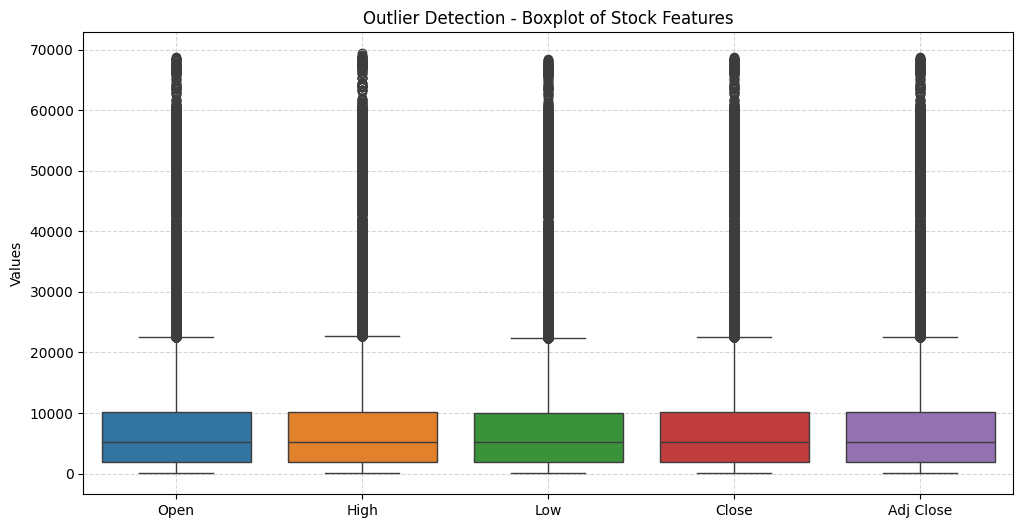

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/mahnazarjmand/stock-market/Market.csv')

features = ['Open', 'High', 'Low', 'Close', 'Adj Close']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features])
plt.title('Outlier Detection - Boxplot of Stock Features')
plt.ylabel('Values')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
cols_to_treat = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

for col in cols_to_treat:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    df[col] = np.where(df[col] > upper_bound, upper_bound,
               np.where(df[col] < lower_bound, lower_bound, df[col]))

print("Outlier Handling Completed via IQR Capping!")

Outlier Handling Completed via IQR Capping!


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
y = df['Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.7662724524275298

Classification Report:
               precision    recall  f1-score   support

   000001.SS       0.90      0.88      0.89      1201
   399001.SZ       0.79      0.80      0.79      1241
       GDAXI       0.63      0.61      0.62      1748
      GSPTSE       0.74      0.73      0.73      2168
         HSI       0.75      0.69      0.72      1744
        IXIC       0.94      0.89      0.91      2488
     J203.JO       0.69      0.98      0.81       479
        KS11       0.99      0.97      0.98      1203
        N100       0.88      0.87      0.88      1079
        N225       0.67      0.72      0.69      2795
        NSEI       0.69      0.75      0.71       734
         NYA       0.69      0.71      0.70      2841
        SSMI       0.68      0.66      0.67      1545
        TWII       0.85      0.79      0.82      1226

    accuracy                           0.77     22492
   macro avg       0.78      0.79      0.78     22492
weighted avg       0